<a href="https://colab.research.google.com/github/jihyejung-400/public/blob/master/Day2_%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%8B%9C%EA%B0%81%ED%99%94_%EA%B5%90%EC%95%88_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Day 2 | 세션 1: 데이터 시각화
**농촌진흥청 데이터 분석 교육**

---

| 파트 | 내용 | 시간 |
|------|------|------|
| **Part 1** | 왜 시각화인가? + matplotlib 기초 구조 | 15분 |
| **Part 2** | matplotlib — 선/막대/산점도/파이 + 꾸미기 | 35분 |
| **Part 3** | seaborn — 더 쉽고 예쁘게 | 30분 |
| **Part 5** | Gen AI로 시각화 코드 수정하기 | 20분 |


## 📌 학습목표

본 세션을 마친 후 학습자는 다음을 수행할 수 있다.

1. matplotlib의 Figure와 Axes 구조를 이해하고 단계별로 그래프를 구성할 수 있다.
2. 분석 목적에 따라 적합한 그래프 종류(선/막대/산점도/히스토그램/파이)를 선택할 수 있다.
3. 제목, 축 이름, 범례, 색상 등 꾸미기 요소를 적용하여 가독성 높은 그래프를 작성할 수 있다.
4. seaborn을 이용하여 matplotlib보다 간결한 코드로 통계 시각화를 수행할 수 있다.
5. 히트맵을 통해 변수 간 상관관계를 시각적으로 파악하고 해석할 수 있다.
6. plotly를 이용하여 마우스 조작이 가능한 인터랙티브 그래프를 작성할 수 있다.
7. 작성한 그래프를 PNG 또는 HTML 파일로 저장하여 보고서에 활용할 수 있다.
8. Gen AI에게 시각화 코드 수정을 요청하여 원하는 결과물을 얻을 수 있다.

---


/tmp/ipykernel_772/2619273850.py:17: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) NanumGothic.
  ax.axis('off'); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


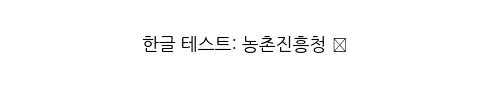

✅ 폰트 등록 완료: NanumGothic


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ⚠️  반드시 가장 먼저 실행하세요! (한글 폰트)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import subprocess
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
subprocess.run(['apt-get','install','-y','-q','fonts-nanum'], capture_output=True)
FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(FONT_PATH)
fp = fm.FontProperties(fname=FONT_PATH)
plt.rcParams['font.family']        = fp.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 한글 출력 확인
fig, ax = plt.subplots(figsize=(5,1))
ax.text(0.5,0.5,'한글 테스트: 농촌진흥청 🌾', ha='center', va='center', fontsize=13)
ax.axis('off'); plt.tight_layout(); plt.show()
print('✅ 폰트 등록 완료:', fp.get_name())


### 📌 plt vs fig/ax 정리

```python
# plt 방식 (그래프 1개일 때 간단)
plt.plot(x, y)
plt.title('제목')
plt.show()

# fig, ax 방식 (그래프 여러 개, 세밀한 제어)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y)
ax.set_title('제목')
plt.show()

# 여러 개 나란히
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(x, y)    # 왼쪽
axes[1].bar(x, y)     # 오른쪽
plt.tight_layout()    # 간격 자동 조정
plt.show()
```

> 💡 이 강의에서는 **fig, ax 방식**을 주로 씁니다.
> 처음엔 낯설어도 코드 구조가 일관되어 이해하기 쉬워집니다!


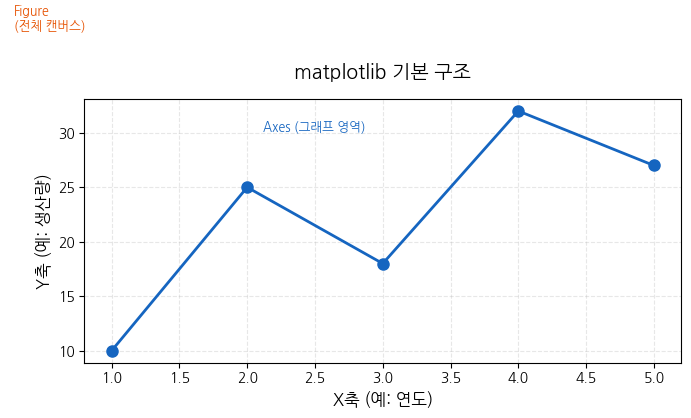

💡 fig = 전체 종이, ax = 그래프를 그리는 영역


In [ ]:
# ── matplotlib 기본 구조 이해 ──
fig, ax = plt.subplots(figsize=(7, 4))  #캔버스

x = [1, 2, 3, 4, 5]
y = [10, 25, 18, 32, 27]

ax.plot(x, y, color='#1565C0', linewidth=2, marker='o', markersize=8)

# 꾸미기 요소들
ax.set_title('matplotlib 기본 구조', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('X축 (예: 연도)', fontsize=12)
ax.set_ylabel('Y축 (예: 생산량)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

# 구조 설명 화살표
ax.annotate('Figure\n(전체 캔버스)', xy=(0.02, 0.97),
            xycoords='figure fraction', fontsize=9,
            color='#E65100', fontweight='bold')
ax.annotate('Axes (그래프 영역)', xy=(0.3, 0.88),
            xycoords='axes fraction', fontsize=9,
            color='#1565C0', fontweight='bold')

plt.tight_layout()
plt.show()
print('💡 fig = 전체 종이, ax = 그래프를 그리는 영역')


In [ ]:
# ── 세션1+2 + 머신러닝 데이터 불러오기 ──
import pandas as pd
import numpy as np
from google.colab import files
print('농작물_정제완료.xlsx 를 업로드하세요')
uploaded = files.upload()
fname = list(uploaded.keys())[0]
df = pd.read_excel(fname)

# 파생변수
df['총수익(억)'] = (df['생산량(톤)'] * 1000 * df['단가(원/kg)'] / 1e8).round(2)
df['단위생산량'] = (df['생산량(톤)'] / df['재배면적(ha)']).round(2)

print(f'✅ 로드 완료: {df.shape}')
print(f'컬럼: {list(df.columns)}')
df.head()


농작물_정제완료.xlsx 를 업로드하세요


Saving 농작물_정제완료.xlsx to 농작물_정제완료 (1).xlsx
✅ 로드 완료: (126, 16)
컬럼: ['연도', '시군구', '작물', '재배면적(ha)', '생산량(톤)', '단가(원/kg)', '조사일자', '지역코드', '생산등급', '수분함량(%)', '생산등급_숫자', '수분함량_숫자', '월', '일', '총수익(억)', '단위생산량']


,연도,시군구,작물,재배면적(ha),생산량(톤),단가(원/kg),조사일자,지역코드,생산등급,수분함량(%),생산등급_숫자,수분함량_숫자,월,일,총수익(억),단위생산량
0,2019,수원시,딸기,190.5,1404.4,7854,2019-05-01,KR-GG-001,1등급,84%,1,84,5,1,110.30,7.37
1,2019,성남시,쌀,250.3,2100.0,2100,2019-06-15,KR-GG-002,2등급,80%,2,80,6,15,44.10,8.39
2,2019,평택시,감자,120.0,960.0,1362,2019-08-10,KR-GG-004,1등급,73%,1,73,8,10,13.08,8.00
3,2019,이천시,배추,55.2,414.0,550,2019-10-11,KR-GG-006,3등급,88%,3,88,10,11,2.28,7.50
4,2019,여주시,오이,72.1,385.0,900,2019-11-05,KR-GG-007,2등급,90%,2,90,11,5,3.46,5.34


---
## 1-3. plt, fig, ax — 하나씩 이해하기

> 갑자기 `fig, ax = plt.subplots()` 보면 당황스럽죠?
> 처음부터 하나씩 쌓아가며 이해해봅시다.


### 🟢 Step 1. `plt`만으로 그리기 — 가장 간단한 방법

```python
import matplotlib.pyplot as plt
```
`plt`는 matplotlib의 별명입니다. 이것만으로도 그래프를 그릴 수 있어요.


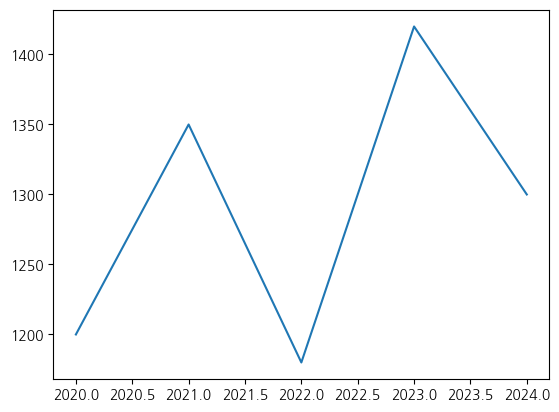

In [ ]:
# Step 1: plt만 사용 — 가장 간단
x = [2020, 2021, 2022, 2023, 2024]
y = [1200, 1350, 1180, 1420, 1300]

plt.plot(x, y)   # 그냥 바로 그리기
plt.show()       # 화면에 출력

# 🔍 확인: 그래프가 나오긴 하는데 제목도 없고 좀 허전하죠?


### 🟡 Step 2. `plt`로 꾸며보기

`plt.title()`, `plt.xlabel()` 등으로 꾸밀 수 있어요.
하지만 그래프가 여러 개이면 관리하기 어려워집니다.


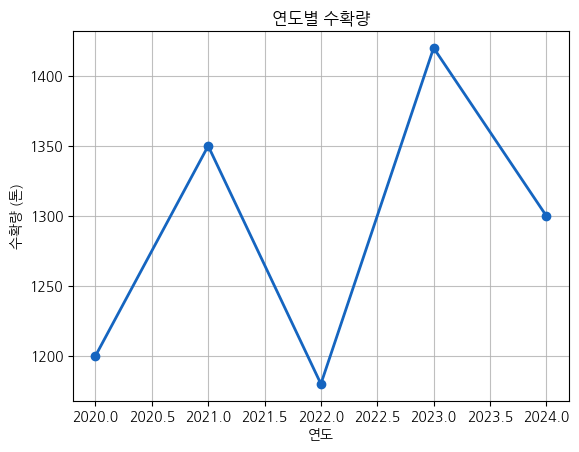

In [ ]:
# Step 2: plt로 꾸미기 (그림1개 그릴때)
plt.plot(x, y, color='#1565C0', linewidth=2, marker='o')
plt.title('연도별 수확량')    # 제목
plt.xlabel('연도')            # x축 이름
plt.ylabel('수확량 (톤)')     # y축 이름
plt.grid(True, alpha=0.8)    # 격자
plt.show()

# 🔍 꾸미니까 훨씬 낫죠?
# 하지만 그래프가 2개 이상이면 plt 방식은 헷갈립니다


### 🔵 Step 3. `fig`와 `ax` 등장 — 왜 필요한가?

```
fig = 도화지 (전체 캔버스)
ax  = 도화지 위의 그림 영역 (실제로 그래프가 그려지는 곳)
```

도화지(fig)를 먼저 만들고, 그 위에 그림 영역(ax)을 배치하는 방식입니다.

```python
fig, ax = plt.subplots()  # 도화지 + 그림영역 동시 생성
#  ↑     ↑
# 도화지  그림영역
```


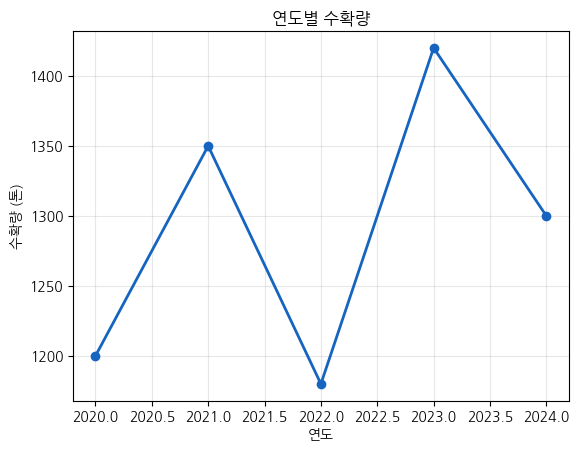

In [ ]:
# Step 3: fig, ax 방식으로 같은 그래프 그리기 (그래프 여러개 그릴때 ax로 각각 조절)
fig, ax = plt.subplots()   # 도화지(fig) + 그림영역(ax) 생성

ax.plot(x, y, color='#1565C0', linewidth=2, marker='o')

# plt.xxx() 대신 ax.set_xxx() 로 꾸밉니다
ax.set_title('연도별 수확량')   # ← plt.title() 이 ax.set_title() 로
ax.set_xlabel('연도')           # ← plt.xlabel() 이 ax.set_xlabel() 로
ax.set_ylabel('수확량 (톤)')    # ← plt.ylabel() 이 ax.set_ylabel() 로
ax.grid(True, alpha=0.3)

plt.show()

# 🔍 결과는 똑같아 보이지만
# ax 방식은 그래프가 여러 개일 때 훨씬 관리하기 편합니다!


### 🟠 Step 4. `figsize` — 그래프 크기 조절

```python
fig, ax = plt.subplots(figsize=(가로, 세로))
#                               ↑     ↑
#                              인치 단위
```


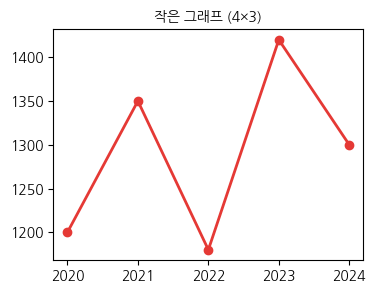

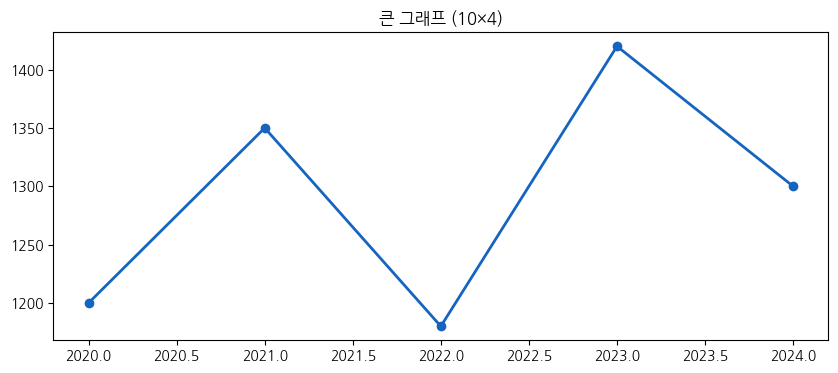

In [ ]:
# Step 4: figsize로 크기 조절
# 작은 그래프
fig, ax = plt.subplots(figsize=(4, 3))   # 가로4, 세로3 인치
ax.plot(x, y, color='#E53935', linewidth=2, marker='o')
ax.set_title('작은 그래프 (4×3)', fontsize=10)
plt.show()

# 큰 그래프
fig, ax = plt.subplots(figsize=(10, 4))  # 가로10, 세로4 인치
ax.plot(x, y, color='#1565C0', linewidth=2, marker='o')
ax.set_title('큰 그래프 (10×4)', fontsize=12)
plt.show()

# 🔍 강의에서 주로 figsize=(10,5) 또는 (13,5) 정도를 씁니다


### 🔴 Step 5. `subplots` — 그래프 여러 개 나란히

```python
fig, axes = plt.subplots(행, 열, figsize=(가로, 세로))
#                        ↑   ↑
#                       1행 2열 = 나란히 2개
```

이때 `axes`는 ax가 여러 개이므로 복수형으로 씁니다.
각 그래프는 `axes[0]`, `axes[1]`로 접근합니다.


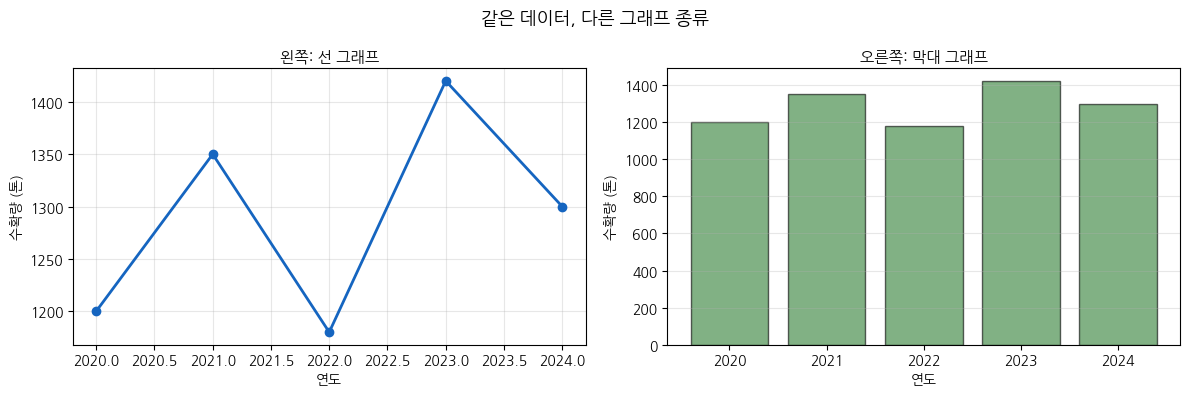

In [ ]:
# Step 5: subplots로 그래프 2개 나란히
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#                        ↑  ↑
#                       1행 2열

# 왼쪽 그래프: axes[0]
axes[0].plot(x, y, color='#1565C0', linewidth=2, marker='o')
axes[0].set_title('왼쪽: 선 그래프', fontsize=11, fontweight='bold')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('수확량 (톤)')
axes[0].grid(True, alpha=0.3)

# 오른쪽 그래프: axes[1]
axes[1].bar(x, y, color='#2E7D32', alpha=0.6, edgecolor='black')                 #alpha 그래프 투명도 , edgecolor 막대 바깥부분
axes[1].set_title('오른쪽: 막대 그래프', fontsize=11, fontweight='bold')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('수확량 (톤)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('같은 데이터, 다른 그래프 종류', fontsize=13, fontweight='bold')
plt.tight_layout()  # 그래프 간격 자동 조정
plt.show()


### 🟣 Step 6. 2행 2열 — 4개 그래프 한번에

```python
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes[0][0] = 왼쪽위  axes[0][1] = 오른쪽위
# axes[1][0] = 왼쪽아래  axes[1][1] = 오른쪽아래
```


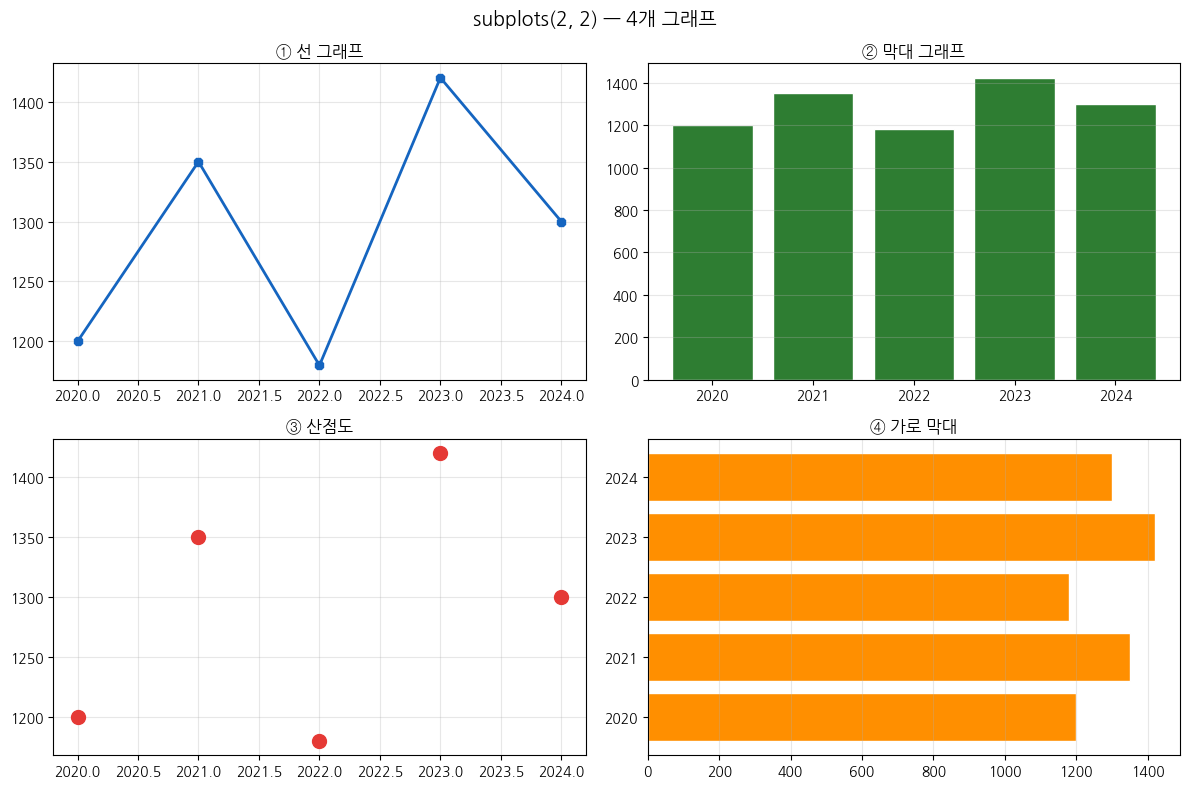

In [ ]:
# Step 6: 2x2 배치
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 왼쪽 위 [0][0]
axes[0][0].plot(x, y, color='#1565C0', marker='8', linewidth=2)
axes[0][0].set_title('① 선 그래프', fontweight='bold')
axes[0][0].grid(True, alpha=0.3)

# 오른쪽 위 [0][1]
axes[0][1].bar(x, y, color='#2E7D32', edgecolor='white')
axes[0][1].set_title('② 막대 그래프', fontweight='bold')
axes[0][1].grid(True, alpha=0.3, axis='y')

# 왼쪽 아래 [1][0]
axes[1][0].scatter(x, y, color='#E53935', s=100, zorder=3)
axes[1][0].set_title('③ 산점도', fontweight='bold')
axes[1][0].grid(True, alpha=0.3)

# 오른쪽 아래 [1][1]
axes[1][1].barh(x, y, color='#FF8F00', edgecolor='white')
axes[1][1].set_title('④ 가로 막대', fontweight='bold')
axes[1][1].grid(True, alpha=0.3, axis='x')

plt.suptitle('subplots(2, 2) — 4개 그래프', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
# 🟦 Part 2. matplotlib 기초 `(35분)`

## 2-1. 그래프 종류 선택 가이드

| 상황 | 그래프 | 코드 |
|------|--------|------|
| 시간에 따른 변화 | **선 그래프** | `ax.plot()` |
| 항목별 비교 | **막대 그래프** | `ax.bar()` |
| 두 변수 관계 | **산점도** | `ax.scatter()` |
| 비율/구성 | **파이 차트** | `ax.pie()` |
| 분포 확인 | **히스토그램** | `ax.hist()` |
| 이상값 탐지 | **박스플롯** | `ax.boxplot()` |


## 2-2. 선 그래프 — 연도별 추이

언제: **시간에 따른 변화**를 볼 때
농업 예시: 연도별 작물 생산량 변화


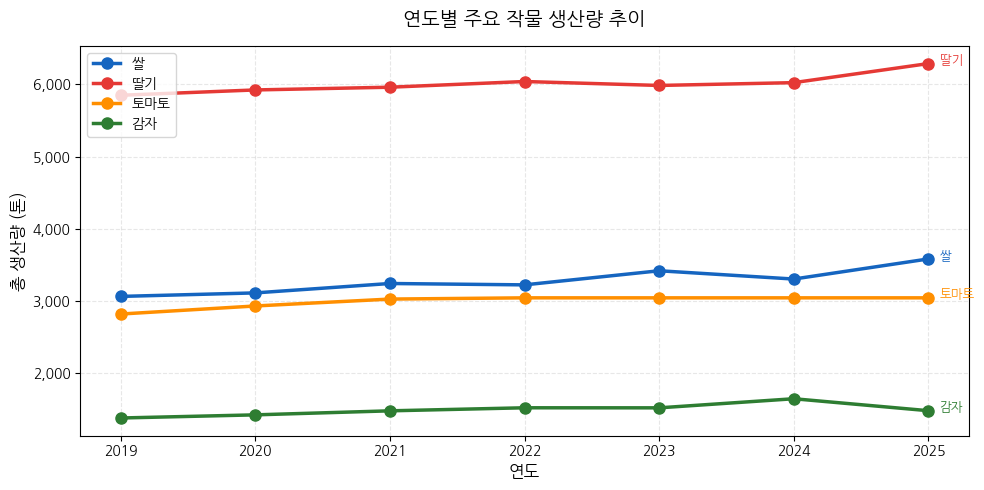

In [ ]:
# ── 선 그래프: 연도별 작물별 생산량 추이 ──
연도별 = df.groupby(['연도','작물'])['생산량(톤)'].sum().reset_index()  #요약
주요작물 = ['쌀','딸기','토마토','감자']
colors = ['#1565C0','#E53935','#FF8F00','#2E7D32']

fig, ax = plt.subplots(figsize=(10, 5))

for 작물, color in zip(주요작물, colors):
    data = 연도별[연도별['작물'] == 작물]
    ax.plot(data['연도'], data['생산량(톤)'],
            marker='o', linewidth=2.5, markersize=8,
            color=color, label=작물)
    # 마지막 값에 레이블
    ax.annotate(f'{작물}',
                xy=(data['연도'].iloc[-1], data['생산량(톤)'].iloc[-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=color, fontweight='bold')

ax.set_title('연도별 주요 작물 생산량 추이', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('총 생산량 (톤)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.tight_layout()
plt.show()


## 2-3. 막대 그래프 — 항목별 비교

언제: **카테고리 간 크기 비교**할 때
농업 예시: 작물별 평균 단가 비교


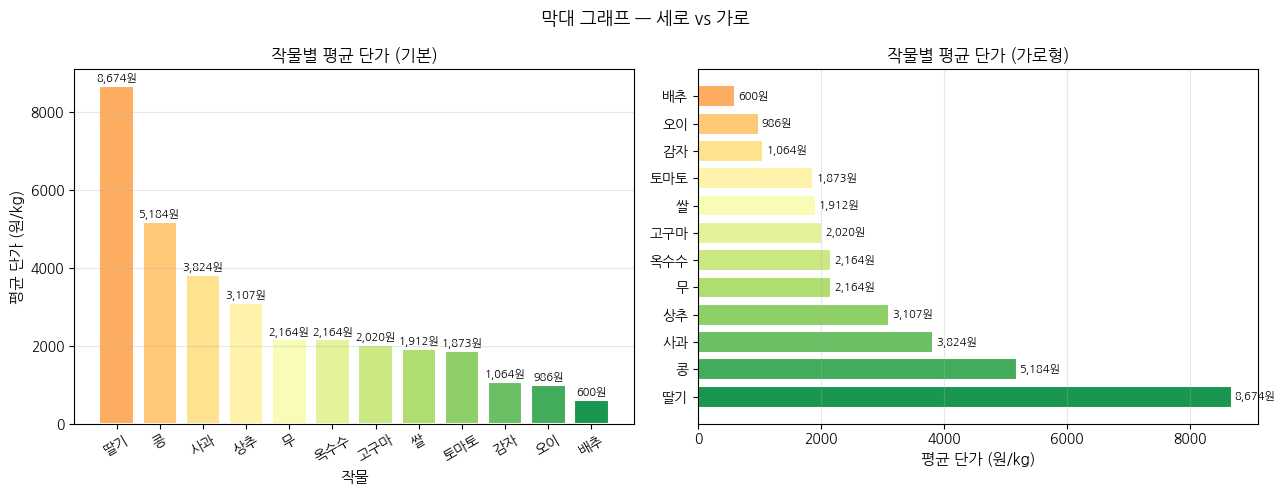

In [ ]:
# ── 막대 그래프: 작물별 평균 단가 비교 ──
작물단가 = df.groupby('작물')['단가(원/kg)'].mean().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 기본 막대
ax1 = axes[0]
bar_colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(작물단가)))
bars = ax1.bar(작물단가['작물'], 작물단가['단가(원/kg)'],
               color=bar_colors, edgecolor='white', linewidth=1.5)

# 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{height:,.0f}원', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_title('작물별 평균 단가 (기본)', fontsize=12, fontweight='bold')
ax1.set_xlabel('작물', fontsize=11)
ax1.set_ylabel('평균 단가 (원/kg)', fontsize=11)
ax1.tick_params(axis='x', rotation=30)
ax1.grid(True, alpha=0.3, axis='y')

# 오른쪽: 가로 막대 (항목 많을 때 유용)
ax2 = axes[1]
bars2 = ax2.barh(작물단가['작물'], 작물단가['단가(원/kg)'],
                 color=bar_colors[::-1], edgecolor='white', linewidth=1.5)       #color순서 역순 -1
for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 50, bar.get_y() + bar.get_height()/2.,
             f'{width:,.0f}원', ha='left', va='center', fontsize=8, fontweight='bold')

ax2.set_title('작물별 평균 단가 (가로형)', fontsize=12, fontweight='bold')
ax2.set_xlabel('평균 단가 (원/kg)', fontsize=11)
ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle('막대 그래프 — 세로 vs 가로', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 2-4. 산점도 — 두 변수의 관계

언제: **두 변수 사이에 관계가 있는지** 볼 때
농업 예시: 재배면적과 생산량의 관계 (클수록 많이 생산?)


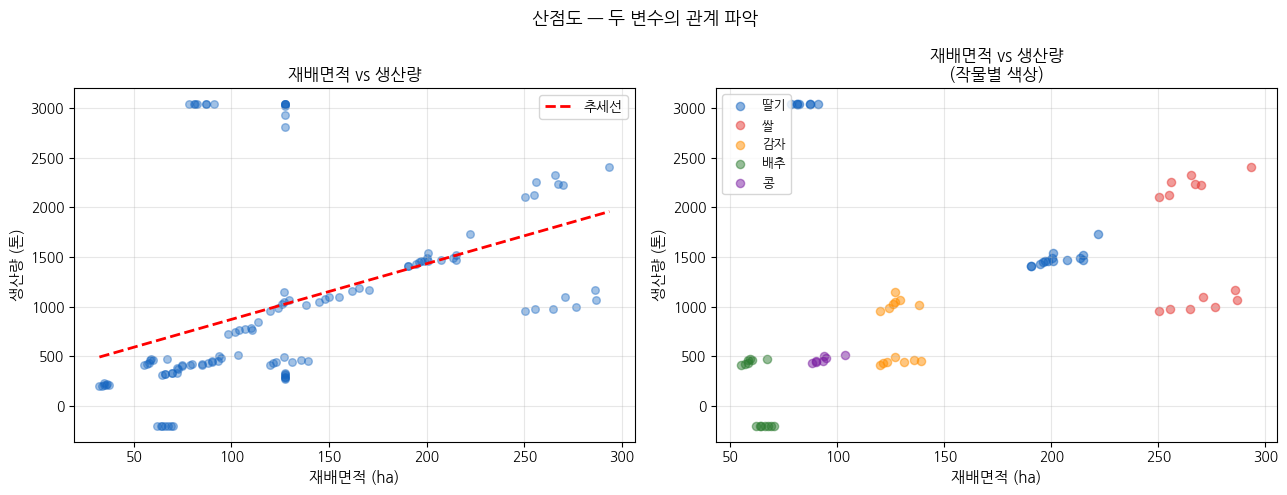

In [ ]:
# ── 산점도: 재배면적 vs 생산량 ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 기본 산점도(scatter)
ax1 = axes[0]
ax1.scatter(df['재배면적(ha)'], df['생산량(톤)'],
            alpha=0.4, s=30, color='#1565C0')

# 추세선 추가
# 두 컬럼 동시에 결측값 제거 (길이가 같아야 함)
df_clean = df[['재배면적(ha)','생산량(톤)']].dropna()
z = np.polyfit(df_clean['재배면적(ha)'], df_clean['생산량(톤)'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['재배면적(ha)'].min(), df['재배면적(ha)'].max(), 100)
ax1.plot(x_line, p(x_line), 'r--', linewidth=2, label='추세선')

ax1.set_title('재배면적 vs 생산량', fontsize=12, fontweight='bold')
ax1.set_xlabel('재배면적 (ha)', fontsize=11)
ax1.set_ylabel('생산량 (톤)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 오른쪽: 작물별 색상 구분
ax2 = axes[1]
주요작물 = df['작물'].value_counts().head(5).index
palette = ['#1565C0','#E53935','#FF8F00','#2E7D32','#7B1FA2']
for 작물, color in zip(주요작물, palette):
    sub = df[df['작물'] == 작물]
    ax2.scatter(sub['재배면적(ha)'], sub['생산량(톤)'],
               alpha=0.5, s=35, color=color, label=작물)

ax2.set_title('재배면적 vs 생산량\n(작물별 색상)', fontsize=12, fontweight='bold')
ax2.set_xlabel('재배면적 (ha)', fontsize=11)
ax2.set_ylabel('생산량 (톤)', fontsize=11)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.3)

plt.suptitle('산점도 — 두 변수의 관계 파악', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 2-5. 히스토그램 + 박스플롯 — 분포 확인

언제: **데이터가 어떻게 퍼져있는지** 볼 때
농업 예시: 단가 분포, 이상값 탐지


/tmp/ipykernel_772/1483146741.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_box, labels=주요작물, patch_artist=True)


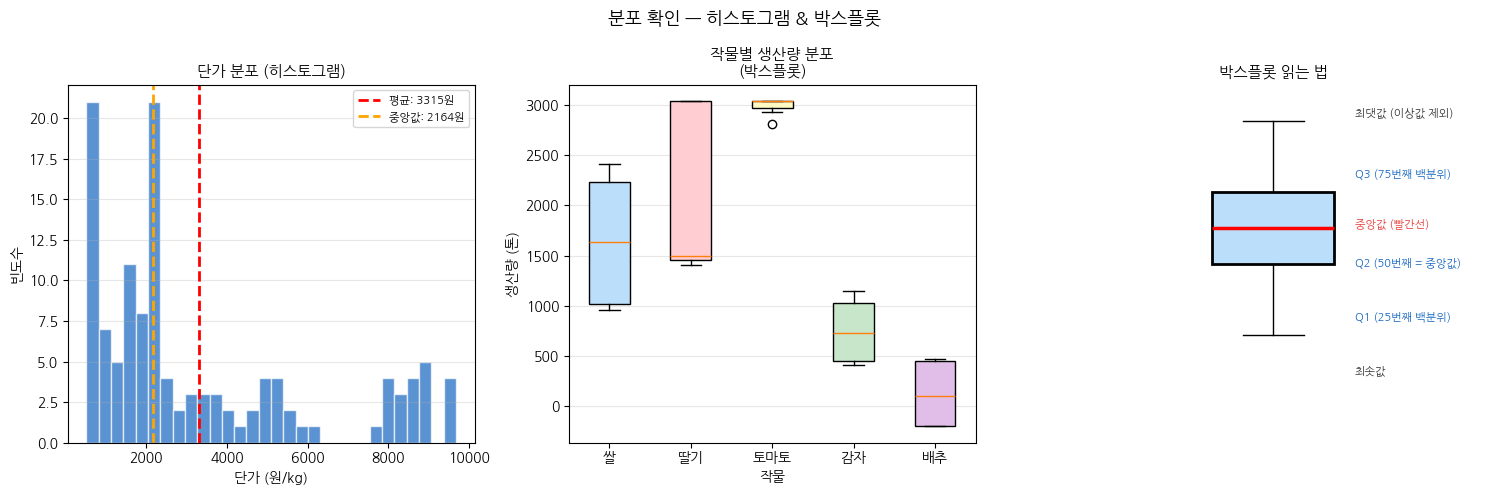

In [ ]:
# ── 히스토그램 + 박스플롯 ── (연속변수가 1개일때 or 카테고리 변수가 있을때)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 히스토그램
ax1 = axes[0]
ax1.hist(df['단가(원/kg)'].dropna(), bins=30,
         color='#1565C0', alpha=0.7, edgecolor='white')
ax1.axvline(df['단가(원/kg)'].mean(), color='red', lw=2,
            linestyle='--', label=f'평균: {df["단가(원/kg)"].mean():.0f}원')
ax1.axvline(df['단가(원/kg)'].median(), color='orange', lw=2,
            linestyle='--', label=f'중앙값: {df["단가(원/kg)"].median():.0f}원')
ax1.set_title('단가 분포 (히스토그램)', fontsize=11, fontweight='bold')
ax1.set_xlabel('단가 (원/kg)', fontsize=10)
ax1.set_ylabel('빈도수', fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

# 박스플롯: 작물별
ax2 = axes[1]
주요작물 = ['쌀','딸기','토마토','감자','배추']
data_box = [df[df['작물']==c]['생산량(톤)'].dropna().values for c in 주요작물]
bp = ax2.boxplot(data_box, labels=주요작물, patch_artist=True)
colors_box = ['#BBDEFB','#FFCDD2','#FFF9C4','#C8E6C9','#E1BEE7']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax2.set_title('작물별 생산량 분포\n(박스플롯)', fontsize=11, fontweight='bold')
ax2.set_xlabel('작물', fontsize=10)
ax2.set_ylabel('생산량 (톤)', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# 박스플롯 읽는 법
ax3 = axes[2]
ax3.set_xlim(0,10); ax3.set_ylim(0,10); ax3.axis('off')
ax3.set_facecolor('#F8F9FA')
example_data = [3,4,5,5,6,6,6,7,7,8,9]
bp2 = ax3.boxplot(example_data, positions=[5], widths=[3],
                  patch_artist=True,
                  boxprops=dict(facecolor='#BBDEFB', linewidth=2),
                  medianprops=dict(color='red', linewidth=2.5))
labels_box = [
    (5.0, 9.2, '최댓값 (이상값 제외)', '#333'),
    (5.0, 7.5, 'Q3 (75번째 백분위)', '#1565C0'),
    (5.0, 6.1, '중앙값 (빨간선)', '#E53935'),
    (5.0, 5.0, 'Q2 (50번째 = 중앙값)', '#1565C0'),
    (5.0, 3.5, 'Q1 (25번째 백분위)', '#1565C0'),
    (5.0, 2.0, '최솟값', '#333'),
]
for x,y,txt,col in labels_box:
    ax3.text(7.0, y, txt, fontsize=8, color=col,
             va='center', fontweight='bold')
    ax3.plot([6.5,6.5],[y,y], color=col, lw=0.5, alpha=0.3)
ax3.set_title('박스플롯 읽는 법', fontsize=11, fontweight='bold')

plt.suptitle('분포 확인 — 히스토그램 & 박스플롯', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 2-6. 파이 차트 — 비율/구성

언제: **전체에서 각 부분이 차지하는 비율** 볼 때
농업 예시: 작물별 총생산량 비율


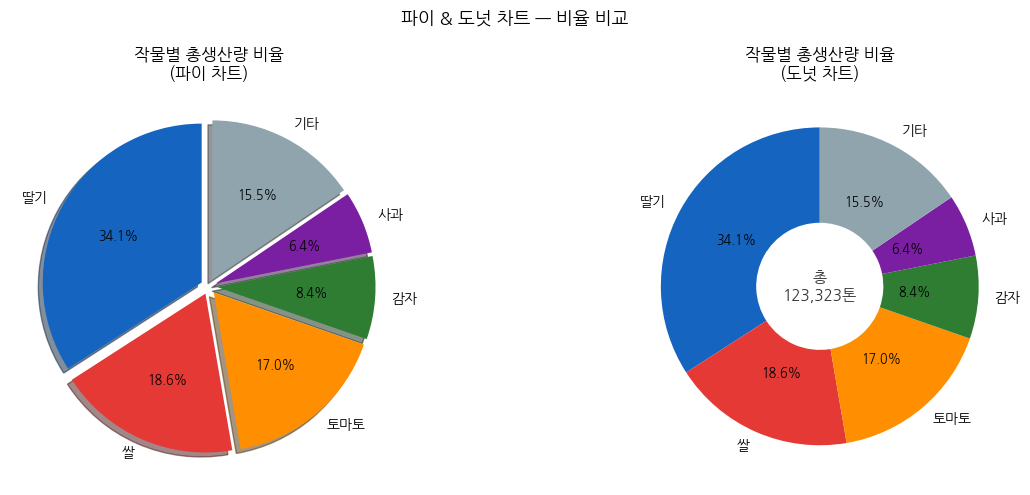

In [ ]:
# ── 파이 차트 + 도넛 차트 ──
작물생산 = df.groupby('작물')['생산량(톤)'].sum().sort_values(ascending=False)
# 상위 5개 + 기타로 묶기
top5 = 작물생산.head(5)
기타 = pd.Series({'기타': 작물생산.iloc[5:].sum()})
파이데이터 = pd.concat([top5, 기타])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pie_colors = ['#1565C0','#E53935','#FF8F00','#2E7D32','#7B1FA2','#90A4AE']

# 왼쪽: 파이 차트
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    파이데이터.values,
    labels=파이데이터.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    explode=[0.05]*len(파이데이터),  # 살짝 분리
    shadow=True
)
for text in autotexts:
    text.set_fontsize(9); text.set_fontweight('bold')
ax1.set_title('작물별 총생산량 비율\n(파이 차트)', fontsize=12, fontweight='bold')

# 오른쪽: 도넛 차트 (가운데 비어있는 파이)
ax2 = axes[1]
wedges2, texts2, autotexts2 = ax2.pie(
    파이데이터.values,
    labels=파이데이터.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    wedgeprops=dict(width=0.6)  # 도넛 두께
)
for text in autotexts2:
    text.set_fontsize(9); text.set_fontweight('bold')
ax2.text(0, 0, f'총\n{파이데이터.sum():,.0f}톤',
         ha='center', va='center', fontsize=11, fontweight='bold', color='#333')
ax2.set_title('작물별 총생산량 비율\n(도넛 차트)', fontsize=12, fontweight='bold')

plt.suptitle('파이 & 도넛 차트 — 비율 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 2-7. 그래프 꾸미기 총정리

```python
# 자주 쓰는 꾸미기 옵션
ax.set_title('제목', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('x축', fontsize=12)
ax.set_ylabel('y축', fontsize=12)
ax.legend(fontsize=10, loc='upper left')   # 범례
ax.grid(True, alpha=0.3, linestyle='--')   # 격자
ax.tick_params(axis='x', rotation=45)      # x축 라벨 회전
ax.set_xlim(0, 100)                        # x축 범위
ax.set_ylim(0, 500)                        # y축 범위

# 색상 지정
color='#1565C0'     # 직접 색상 코드
color='steelblue'   # 이름으로
alpha=0.7           # 투명도 (0=완전 투명, 1=불투명)

# 여러 그래프 배치
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1행 2열
fig, axes = plt.subplots(2, 2, figsize=(12, 10)) # 2행 2열
```


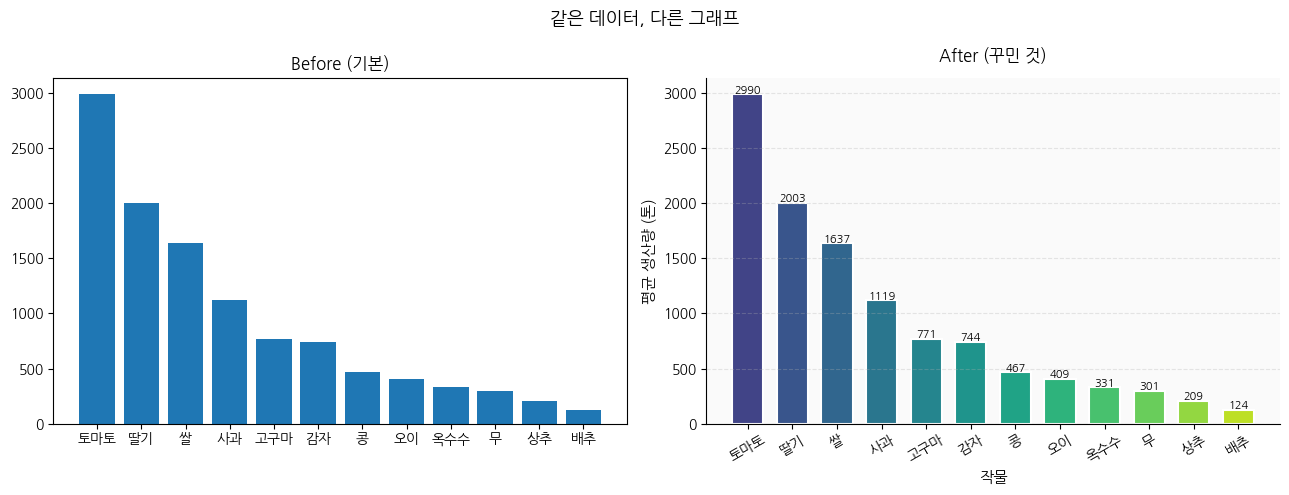

In [ ]:
# ── 꾸미기 Before / After ──
작물별평균 = df.groupby('작물')['생산량(톤)'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before: 기본
axes[0].bar(작물별평균.index, 작물별평균.values)
axes[0].set_title('Before (기본)', fontsize=12)

# After: 꾸민 것
ax2 = axes[1]
bar_colors2 = plt.cm.viridis(np.linspace(0.2, 0.9, len(작물별평균)))
bars = ax2.bar(작물별평균.index, 작물별평균.values,
               color=bar_colors2, edgecolor='white', linewidth=1.5, width=0.7)
for bar in bars:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'{bar.get_height():.0f}', ha='center', fontsize=8, fontweight='bold')
ax2.set_title('After (꾸민 것)', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('작물', fontsize=11)
ax2.set_ylabel('평균 생산량 (톤)', fontsize=11)
ax2.tick_params(axis='x', rotation=30)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.set_facecolor('#FAFAFA')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('같은 데이터, 다른 그래프', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# 🟨 Part 3. seaborn — 더 쉽고 예쁘게 `(30분)`

## 3-1. matplotlib vs seaborn 비교

```python
# 같은 그래프를 그리는 두 가지 방법

# matplotlib (긴 코드)
fig, ax = plt.subplots()
for 작물 in 작물목록:
    sub = df[df['작물']==작물]
    ax.scatter(sub['재배면적'], sub['생산량'], label=작물)
ax.legend()

# seaborn (한 줄!)
sns.scatterplot(data=df, x='재배면적(ha)', y='생산량(톤)', hue='작물')
```

**핵심 차이**: seaborn은 `hue`, `style`, `size` 파라미터로
카테고리별 색상·모양·크기를 자동으로 구분해줍니다.


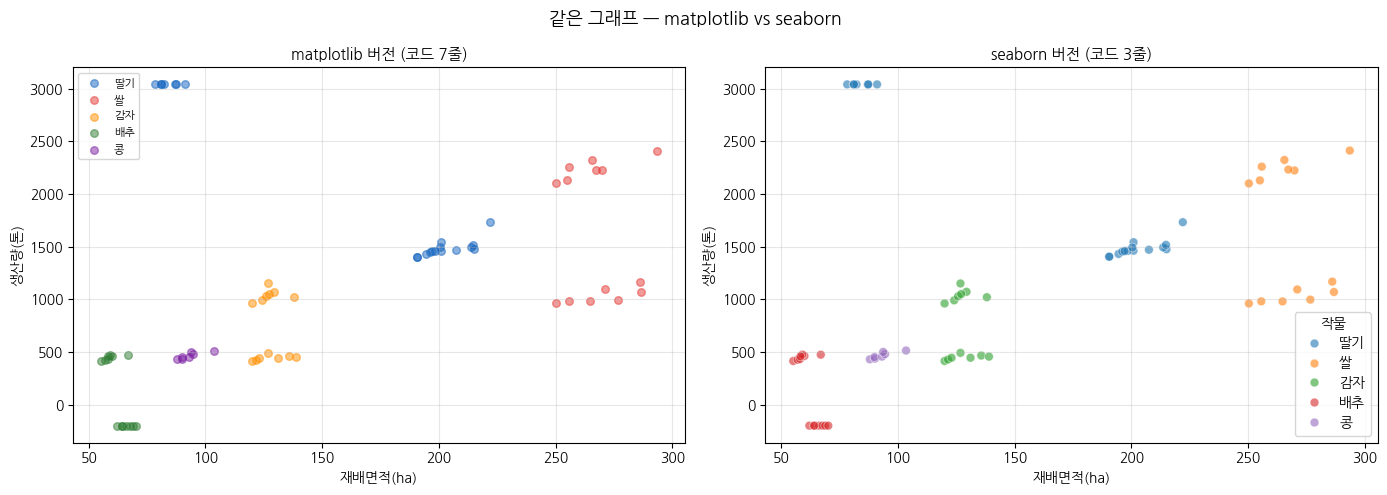

In [ ]:
# ── seaborn 산점도: 재배면적 vs 생산량 (작물별) ──
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# matplotlib 버전
ax1 = axes[0]
주요작물 = df['작물'].value_counts().head(5).index
palette = ['#1565C0','#E53935','#FF8F00','#2E7D32','#7B1FA2']
for 작물, color in zip(주요작물, palette):
    sub = df[df['작물']==작물]
    ax1.scatter(sub['재배면적(ha)'], sub['생산량(톤)'],
               color=color, alpha=0.5, s=30, label=작물)
ax1.legend(fontsize=8)
ax1.set_title('matplotlib 버전 (코드 7줄)', fontsize=11, fontweight='bold')
ax1.set_xlabel('재배면적(ha)'); ax1.set_ylabel('생산량(톤)')
ax1.grid(True, alpha=0.3)

# seaborn 버전
ax2 = axes[1]
sns.scatterplot(data=df[df['작물'].isin(주요작물)],
                x='재배면적(ha)', y='생산량(톤)',
                hue='작물', alpha=0.6, s=40, ax=ax2)
ax2.set_title('seaborn 버전 (코드 3줄)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('같은 그래프 — matplotlib vs seaborn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


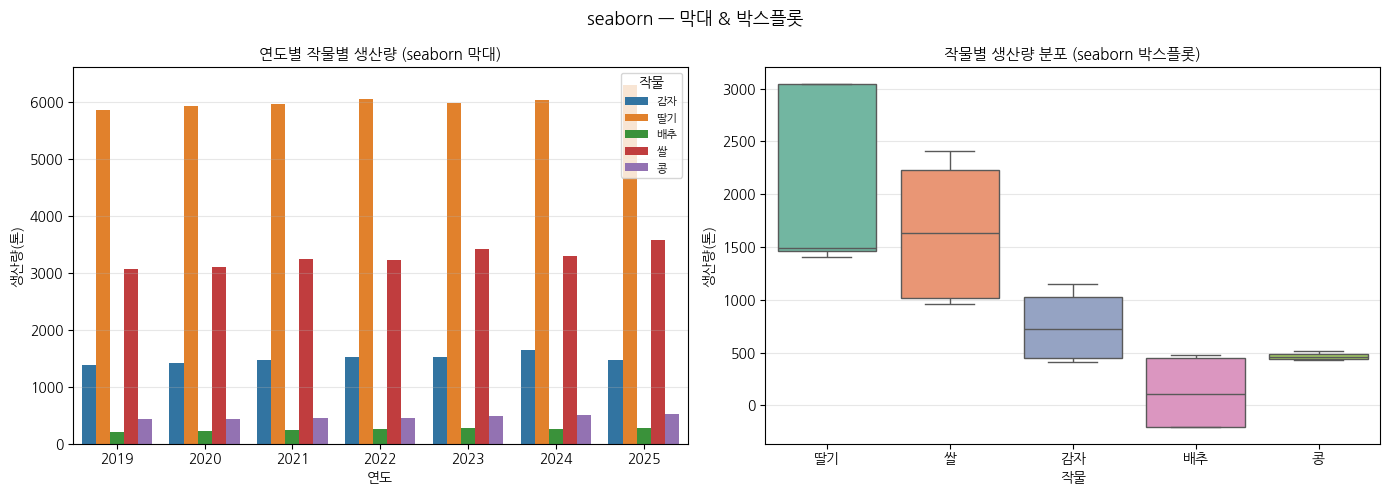

In [ ]:
# ── seaborn 막대 + 박스플롯 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 연도별 작물 생산량 막대
ax1 = axes[0]
주요작물5 = df['작물'].value_counts().head(5).index
df_top5 = df[df['작물'].isin(주요작물5)]
연도별생산 = df_top5.groupby(['연도','작물'])['생산량(톤)'].sum().reset_index()
sns.barplot(data=연도별생산, x='연도', y='생산량(톤)',
            hue='작물', ax=ax1)
ax1.set_title('연도별 작물별 생산량 (seaborn 막대)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, title='작물')
ax1.grid(True, alpha=0.3, axis='y')

# 박스플롯
ax2 = axes[1]
sns.boxplot(data=df_top5, x='작물', y='생산량(톤)',
            hue='작물', palette='Set2', ax=ax2, legend=False)
ax2.set_title('작물별 생산량 분포 (seaborn 박스플롯)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('seaborn — 막대 & 박스플롯', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


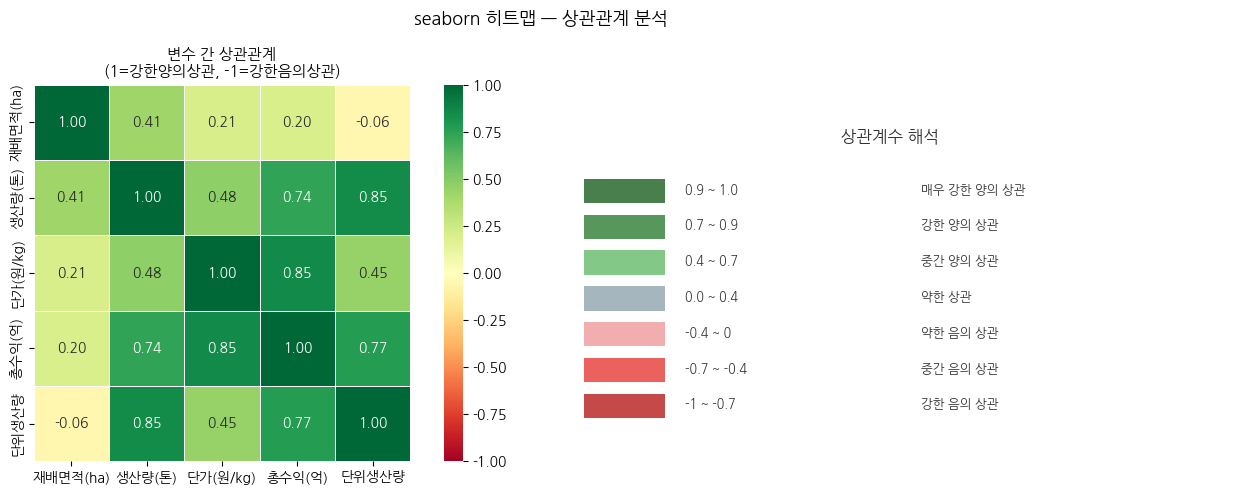

💡 히트맵: 숫자와 색상으로 변수 간 관계를 한눈에!


In [ ]:
# ── seaborn 히트맵 — 상관관계 한눈에 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 상관계수 계산
수치컬럼 = ['재배면적(ha)','생산량(톤)','단가(원/kg)','총수익(억)','단위생산량']
corr = df[수치컬럼].corr()

# 히트맵
ax1 = axes[0]
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,                        #값범위
            square=True, linewidths=0.5, ax=ax1,
            annot_kws={'size':10})
ax1.set_title('변수 간 상관관계\n(1=강한양의상관, -1=강한음의상관)',
              fontsize=11, fontweight='bold')

# pairplot 대신 수동으로 산점도 행렬
ax2 = axes[1]
ax2.set_xlim(0,10); ax2.set_ylim(0,10); ax2.axis('off')
ax2.set_facecolor('#F8F9FA')
ax2.text(5, 8.5, ' 상관계수 해석', ha='center', fontsize=12,
         fontweight='bold', color='#333')
해석목록 = [
    ('0.9 ~ 1.0', '매우 강한 양의 상관', '#1B5E20'),
    ('0.7 ~ 0.9', '강한 양의 상관',     '#2E7D32'),
    ('0.4 ~ 0.7', '중간 양의 상관',     '#66BB6A'),
    ('0.0 ~ 0.4', '약한 상관',          '#90A4AE'),
    ('-0.4 ~ 0', '약한 음의 상관',      '#EF9A9A'),
    ('-0.7 ~ -0.4','중간 음의 상관',    '#E53935'),
    ('-1 ~ -0.7', '강한 음의 상관',     '#B71C1C'),
]
for i, (범위, 설명, col) in enumerate(해석목록):
    y = 7.2 - i*0.95
    ax2.add_patch(plt.Rectangle((0.5, y-0.35), 1.2, 0.65,
                                fc=col, alpha=0.8))
    ax2.text(2.0, y, f'{범위}', fontsize=9, va='center', color='#333')
    ax2.text(5.5, y, 설명, fontsize=9, va='center', color='#333')

plt.suptitle('seaborn 히트맵 — 상관관계 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 히트맵: 숫자와 색상으로 변수 간 관계를 한눈에!')


/tmp/ipykernel_772/1931558227.py:34: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


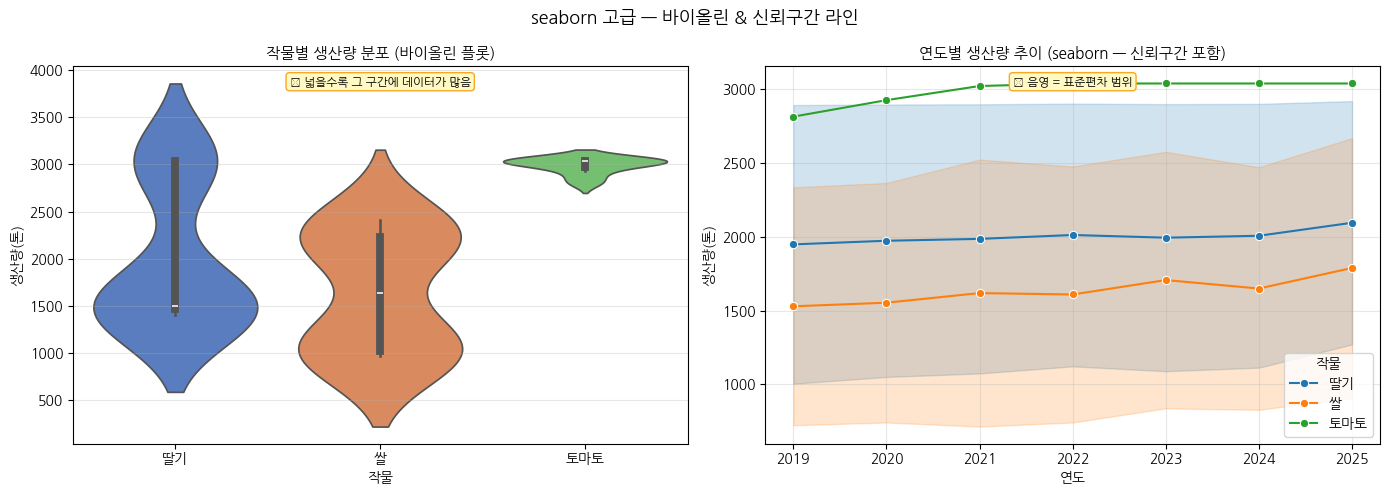

In [ ]:
# ── seaborn 바이올린 + 라인 플롯 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 바이올린 플롯: 박스플롯 + 분포를 동시에
ax1 = axes[0]
주요작물3 = ['쌀','딸기','토마토']
sns.violinplot(data=df[df['작물'].isin(주요작물3)],
               x='작물', y='생산량(톤)',
               hue='작물', palette='muted',
               ax=ax1, legend=False)
ax1.set_title('작물별 생산량 분포 (바이올린 플롯)', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.text(0.5, 0.95,
         '💡 넓을수록 그 구간에 데이터가 많음',
         transform=ax1.transAxes, ha='center', fontsize=8.5,
         bbox=dict(boxstyle='round', fc='#FFF9C4', ec='#F9A825'))

# 라인 플롯: 신뢰구간 포함
ax2 = axes[1]
연도별_top3 = df[df['작물'].isin(주요작물3)].groupby(
    ['연도','작물'])['생산량(톤)'].agg(['mean','std']).reset_index()
sns.lineplot(data=df[df['작물'].isin(주요작물3)],
             x='연도', y='생산량(톤)',
             hue='작물', marker='o',
             errorbar='sd', ax=ax2)
ax2.set_title('연도별 생산량 추이 (seaborn — 신뢰구간 포함)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.text(0.5, 0.95,
         '💡 음영 = 표준편차 범위',
         transform=ax2.transAxes, ha='center', fontsize=8.5,
         bbox=dict(boxstyle='round', fc='#FFF9C4', ec='#F9A825'))

plt.suptitle('seaborn 고급 — 바이올린 & 신뢰구간 라인', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# 🟩 Part 4. plotly — 인터랙티브 그래프 `(20분)`

## 4-1. matplotlib vs plotly

| | matplotlib / seaborn | plotly |
|--|---------------------|--------|
| 결과물 | 정적 이미지 (PNG) | 인터랙티브 HTML |
| 마우스 호버 | ❌ | ✅ 값 자동 표시 |
| 줌 / 이동 | ❌ | ✅ 드래그로 확대 |
| 범례 클릭 | ❌ | ✅ 항목 on/off |
| 용도 | 보고서·논문·저장 | 탐색·발표·대시보드 |
| 코드 양 | 많음 | 적음 (express) |

## 4-2. plotly.express — 한 줄로 인터랙티브 그래프

```python
import plotly.express as px
# matplotlib: for문 돌려서 여러 줄
# plotly:     px.line(df, x='컬럼', y='컬럼', color='작물') → 한 줄!
```

> 🎯 **강사 포인트**: 실행 후 마우스로 직접 만져보게 하세요!
> 학생들 반응이 가장 좋은 순간입니다.


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
print('✅ plotly 임포트 완료')
print('💡 그래프 위에 마우스를 올려보세요!')


✅ plotly 임포트 완료
💡 그래프 위에 마우스를 올려보세요!


## 4-3. 선 그래프 — 연도별 추이

```python
# matplotlib (for문 필요)
for 작물 in 주요작물:
    ax.plot(data['연도'], data['생산량'], label=작물)

# plotly (한 줄!)
px.line(df, x='연도', y='생산량(톤)', color='작물')
```


In [ ]:
주요작물 = ['쌀','딸기','토마토','감자']
연도별 = (df[df['작물'].isin(주요작물)]
          .groupby(['연도','작물'])['생산량(톤)'].sum().reset_index())

fig = px.line(
    연도별,
    x='연도',
    y='생산량(톤)',
    color='작물',
    markers=True,
    title='연도별 작물별 생산량 추이 (인터랙티브)',
    labels={'생산량(톤)': '총 생산량 (톤)'},
)
fig.update_layout(hovermode='x unified', legend_title='작물', font=dict(size=12))
fig.show()

print('💡 해보세요:')
print('  · 선 위에 마우스 → 값 자동 표시')
print('  · 범례 클릭 → 특정 작물 숨기기/보이기')
print('  · 드래그 → 구간 확대 / 🏠 아이콘 → 원래 크기')


💡 해보세요:
  · 선 위에 마우스 → 값 자동 표시
  · 범례 클릭 → 특정 작물 숨기기/보이기
  · 드래그 → 구간 확대 / 🏠 아이콘 → 원래 크기


## 4-4. 막대 그래프 — 작물별 단가 비교


In [ ]:
작물단가 = (df.groupby('작물')['단가(원/kg)'].mean()
            .round(0).reset_index()
            .sort_values('단가(원/kg)', ascending=False))

fig = px.bar(
    작물단가,
    x='작물',
    y='단가(원/kg)',
    color='작물',
    title='작물별 평균 단가 비교',
    text='단가(원/kg)',
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig.update_traces(texttemplate='%{text:,.0f}원', textposition='outside')
fig.update_layout(showlegend=False, yaxis_tickformat=',', font=dict(size=12))
fig.show()
print('💡 막대 위에 마우스 → 정확한 값 표시!')


💡 막대 위에 마우스 → 정확한 값 표시!


## 4-5. 버블 산점도 — 3개 변수 한번에

plotly 산점도의 강점: **`size`로 세 번째 변수까지 표현**

```
x축  = 재배면적
y축  = 생산량
색상 = 작물 종류
크기 = 단가  ← 3번째 변수!
```


In [ ]:
df_s = df[['재배면적(ha)','생산량(톤)','단가(원/kg)','작물','연도']].dropna()
df_s = df_s[df_s['작물'].isin(df['작물'].value_counts().head(5).index)]

fig = px.scatter(
    df_s,
    x='재배면적(ha)',
    y='생산량(톤)',
    color='작물',
    size='단가(원/kg)',           # 버블 크기 = 단가
    hover_data=['연도','단가(원/kg)'],  # 호버 시 추가 정보
    title='재배면적 vs 생산량 (버블 크기 = 단가)',
    labels={'재배면적(ha)':'재배면적 (ha)','생산량(톤)':'생산량 (톤)'},
    opacity=0.7,
)
fig.update_layout(font=dict(size=12))
fig.show()

print('💡 버블이 클수록 단가가 높은 작물!')
print('   점 위에 마우스 → 연도·단가까지 확인!')


💡 버블이 클수록 단가가 높은 작물!
   점 위에 마우스 → 연도·단가까지 확인!


## 4-6. 세 라이브러리 언제 쓰나?

| 상황 | 추천 |
|------|------|
| 보고서·논문에 넣을 그림 | matplotlib |
| 빠르게 탐색, 통계 그래프 | seaborn |
| 발표·대시보드, 인터랙티브 | **plotly** |
| PNG 파일로 저장 | matplotlib / seaborn |
| HTML 파일로 공유 | **plotly** |

```python
# plotly 핵심 요약
import plotly.express as px
px.line(df, x='x', y='y', color='카테고리')       # 선
px.bar(df, x='x', y='y', color='카테고리')        # 막대
px.scatter(df, x='x', y='y',
           color='카테고리', size='크기변수')      # 버블 산점도
fig.show()                   # 출력
fig.write_html('파일.html')  # HTML로 저장
```


In [ ]:
# HTML로 저장해서 공유하기
fig_save = px.bar(
    df.groupby('작물')['생산량(톤)'].sum().reset_index()
      .sort_values('생산량(톤)', ascending=False),
    x='작물', y='생산량(톤)', color='작물',
    title='작물별 총생산량 (인터랙티브)',
    text='생산량(톤)',
)
fig_save.update_traces(texttemplate='%{text:,.0f}톤', textposition='outside')
fig_save.write_html('작물별_생산량.html')
print('✅ 저장 완료: 작물별_생산량.html')
print('   📁 왼쪽 폴더에서 다운로드 → 브라우저에서 열면 인터랙티브!')
fig_save.show()


---
# 🤖 Part 5. Gen AI로 시각화 코드 수정하기 `(20분)`

## 4-1. 이렇게 요청하세요

ChatGPT / Claude에게 시각화 코드 수정을 요청할 때
**좋은 프롬프트 = 현재 코드 + 원하는 변경사항**

### ✅ 좋은 요청 예시
```
아래 matplotlib 코드에서:
1. 막대 색을 작물별로 다르게 해주세요
2. y축을 1,000 단위 쉼표로 표시해주세요
3. 범례를 오른쪽 위로 옮겨주세요
4. 그래프 배경을 흰색으로 바꿔주세요

[코드 붙여넣기]
```

### ❌ 나쁜 요청 예시
```
그래프 예쁘게 해주세요  ← 너무 막연
```

## 4-2. 자주 쓰는 수정 요청 문구

| 원하는 것 | 요청 문구 |
|-----------|----------|
| 색상 변경 | '막대 색을 초록색 계열로 바꿔주세요' |
| 제목 수정 | '제목을 한글로 바꾸고 폰트 크기를 14로 해주세요' |
| 축 범위 | 'y축을 0에서 5000으로 고정해주세요' |
| 값 표시 | '막대 위에 숫자를 표시해주세요' |
| 그래프 크기 | '그래프 크기를 가로 12, 세로 6으로 바꿔주세요' |
| 저장 | '그래프를 PNG로 저장하는 코드 추가해주세요' |


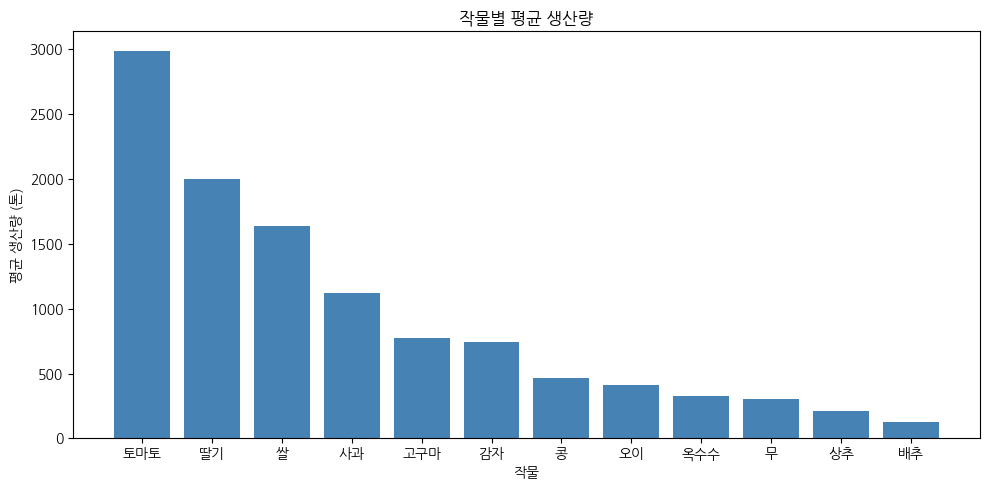

In [ ]:
# ── Gen AI 활용 실습: 이 코드를 복사해서 ChatGPT에 붙여넣고 수정해보세요 ──

# [기본 코드 — 여기서 시작]
작물별생산 = df.groupby('작물')['생산량(톤)'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(작물별생산.index, 작물별생산.values, color='steelblue')
ax.set_title('작물별 평균 생산량')
ax.set_xlabel('작물')
ax.set_ylabel('평균 생산량 (톤)')
plt.tight_layout()
plt.show()

# 💬 ChatGPT/Claude에 이렇게 요청해보세요:
# '위 코드를 수정해서:
# 1. 막대 색을 작물별로 다르게 해주세요
# 2. 막대 위에 값을 표시해주세요
# 3. 그래프 배경을 #F8F9FA로 바꿔주세요
# 4. y축에 천 단위 쉼표를 추가해주세요'

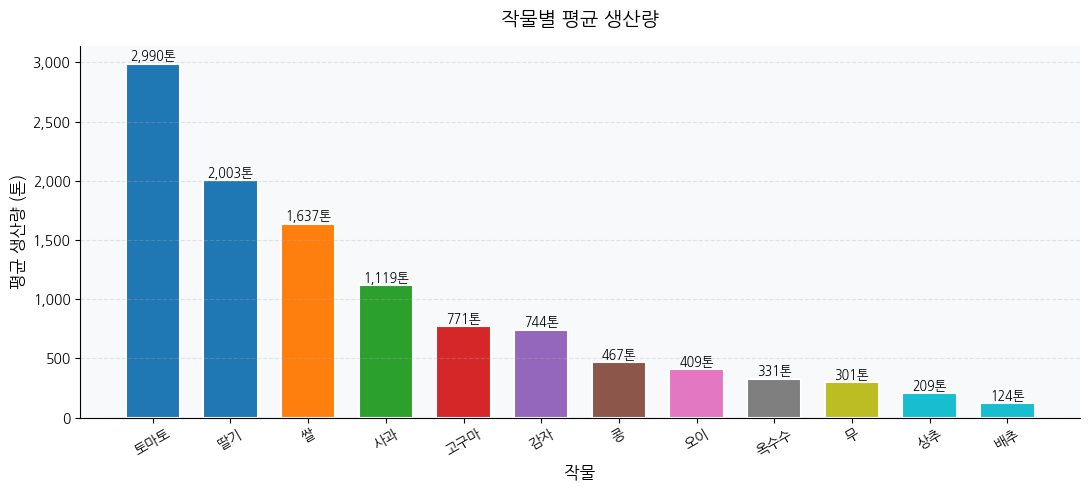

💡 Gen AI에게 요청한 수정사항이 모두 반영되었습니다!


In [ ]:
# ── Gen AI 수정 결과 예시 (직접 실행해보세요) ──
작물별생산 = df.groupby('작물')['생산량(톤)'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')

# 1. 작물별 색상 다르게
colors_custom = plt.cm.tab10(np.linspace(0, 1, len(작물별생산)))
bars = ax.bar(작물별생산.index, 작물별생산.values,
              color=colors_custom, edgecolor='white', linewidth=1.5, width=0.7)

# 2. 막대 위에 값 표시
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f'{bar.get_height():,.0f}톤',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. 꾸미기
ax.set_title('작물별 평균 생산량', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('작물', fontsize=12)
ax.set_ylabel('평균 생산량 (톤)', fontsize=12)
ax.tick_params(axis='x', rotation=30)

# 4. y축 천 단위 쉼표
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print('💡 Gen AI에게 요청한 수정사항이 모두 반영되었습니다!')


In [ ]:
# ── 그래프 저장하기 ──
작물별생산 = df.groupby('작물')['생산량(톤)'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(작물별생산.index, 작물별생산.values,
              color=plt.cm.tab10(np.linspace(0,1,len(작물별생산))))
ax.set_title('작물별 평균 생산량', fontsize=14, fontweight='bold')
ax.set_xlabel('작물'); ax.set_ylabel('평균 생산량 (톤)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# PNG로 저장
plt.savefig('작물별_평균생산량.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 그래프 저장 완료: 작물별_평균생산량.png')
print('   왼쪽 📁 폴더에서 다운로드 가능!')


---
## ✅ 전체 핵심 요약

```python
# ── matplotlib 기본 구조 ──
fig, ax = plt.subplots(figsize=(10,5))  # 캔버스 생성
ax.plot(x, y)          # 선 그래프
ax.bar(x, y)           # 막대 그래프
ax.scatter(x, y)       # 산점도
ax.hist(x, bins=30)    # 히스토그램
ax.boxplot(data)       # 박스플롯
ax.pie(values)         # 파이 차트

# ── 꾸미기 ──
ax.set_title('제목', fontsize=14, fontweight='bold')
ax.set_xlabel('x축'); ax.set_ylabel('y축')
ax.legend()            # 범례
ax.grid(True, alpha=0.3)
plt.savefig('파일.png', dpi=150, bbox_inches='tight')

# ── seaborn (더 쉽고 예쁘게) ──
sns.scatterplot(data=df, x='컬럼', y='컬럼', hue='카테고리')
sns.barplot(data=df, x='컬럼', y='컬럼', hue='카테고리')
sns.boxplot(data=df, x='컬럼', y='컬럼')
sns.violinplot(data=df, x='컬럼', y='컬럼')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn')
sns.lineplot(data=df, x='컬럼', y='컬럼', hue='카테고리')
```

**다음 세션** → 🤖 GPT API 활용 — 템플릿으로 바로 시작하기
